In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

print("Libraries ready")

Libraries ready


In [4]:
# ─── SET YOUR BASE FOLDER PATH HERE ──────────────────────────────────────
# This is the folder in your Google Drive where all CSV files are stored.
BASE = '/content/drive/MyDrive/'  # Change this if files are in a subfolder
# ─────────────────────────────────────────────────────────────────────────

PATHS = {
    'food'          : BASE + 'food.csv',
    'nutrient'      : BASE + 'nutrient.csv',
    'food_nutrient' : BASE + 'food_nutrient.csv',
    'food_category' : BASE + 'food_category.csv',
    'recipes'       : BASE + 'full_dataset.csv',
}

# Verify all files exist before loading
all_found = True
for name, path in PATHS.items():
    exists = os.path.exists(path)
    status = '✅' if exists else '❌ NOT FOUND'
    print(f'{status}  {name:20s} → {path}')
    if not exists:
        all_found = False

if not all_found:
    print('\n⚠️  Some files are missing. Update BASE path above and re-run.')
else:
    print('\n✅ All files found. Proceed to next cell.')

✅  food                 → /content/drive/MyDrive/food.csv
✅  nutrient             → /content/drive/MyDrive/nutrient.csv
✅  food_nutrient        → /content/drive/MyDrive/food_nutrient.csv
✅  food_category        → /content/drive/MyDrive/food_category.csv
✅  recipes              → /content/drive/MyDrive/full_dataset.csv

✅ All files found. Proceed to next cell.


In [5]:
print('Loading datasets...\n')

food_df          = pd.read_csv(PATHS['food'])
nutrient_df      = pd.read_csv(PATHS['nutrient'])
food_nutrient_df = pd.read_csv(PATHS['food_nutrient'])
food_category_df = pd.read_csv(PATHS['food_category'])
recipes_df       = pd.read_csv(PATHS['recipes'])

# Keep only useful recipe columns
recipes_df = recipes_df[['title', 'ingredients']]

print(f'food.csv          → {food_df.shape[0]:,} rows, {food_df.shape[1]} cols')
print(f'nutrient.csv      → {nutrient_df.shape[0]:,} rows, {nutrient_df.shape[1]} cols')
print(f'food_nutrient.csv → {food_nutrient_df.shape[0]:,} rows, {food_nutrient_df.shape[1]} cols')
print(f'food_category.csv → {food_category_df.shape[0]:,} rows, {food_category_df.shape[1]} cols')
print(f'recipes           → {recipes_df.shape[0]:,} rows, {recipes_df.shape[1]} cols')

Loading datasets...

food.csv          → 7,793 rows, 5 cols
nutrient.csv      → 474 rows, 5 cols
food_nutrient.csv → 644,125 rows, 11 cols
food_category.csv → 28 rows, 3 cols
recipes           → 2,231,142 rows, 2 cols


In [6]:
print('── food_category ──')
display(food_category_df.head(3))

print('── food ──')
display(food_df.head(3))

print('── nutrient ──')
display(nutrient_df.head(3))

print('── food_nutrient ──')
display(food_nutrient_df.head(3))

print('── recipes ──')
display(recipes_df.head(3))

── food_category ──


,id,code,description
0,1,100,Dairy and Egg Products
1,2,200,Spices and Herbs
2,3,300,Baby Foods


── food ──


,fdc_id,data_type,description,food_category_id,publication_date
0,167512,sr_legacy_food,"Pillsbury Golden Layer Buttermilk Biscuits, Ar...",18,2019-04-01
1,167513,sr_legacy_food,"Pillsbury, Cinnamon Rolls with Icing, refriger...",18,2019-04-01
2,167514,sr_legacy_food,"Kraft Foods, Shake N Bake Original Recipe, Coa...",18,2019-04-01


── nutrient ──


,id,name,unit_name,nutrient_nbr,rank
0,2047,Energy (Atwater General Factors),KCAL,957.0,280.0
1,2048,Energy (Atwater Specific Factors),KCAL,958.0,290.0
2,1001,Solids,G,201.0,200.0


── food_nutrient ──


,id,fdc_id,nutrient_id,amount,data_points,derivation_id,min,max,median,footnote,min_year_acquired
0,1283674,167512,1003,5.88,1,46.0,NaN,NaN,NaN,NaN,NaN
1,1283675,167512,1007,3.50,1,46.0,NaN,NaN,NaN,NaN,NaN
2,1283676,167512,1062,1286.00,0,49.0,NaN,NaN,NaN,NaN,NaN


── recipes ──


,title,ingredients
0,No-Bake Nut Cookies,"[""1 c. firmly packed brown sugar"", ""1/2 c. eva..."
1,Jewell Ball'S Chicken,"[""1 small jar chipped beef, cut up"", ""4 boned ..."
2,Creamy Corn,"[""2 (16 oz.) pkg. frozen corn"", ""1 (8 oz.) pkg..."


In [7]:
# ── Clean food_category ──────────────────────────────────────────────────
food_category_df = food_category_df[['id', 'description']].rename(
    columns={'id': 'food_category_id', 'description': 'category_name'}
)

# ── Clean food ───────────────────────────────────────────────────────────
food_df = food_df[['fdc_id', 'description', 'food_category_id']].rename(
    columns={'description': 'food_name'}
)
# Standardise food name: lowercase, strip whitespace
food_df['food_name_clean'] = food_df['food_name'].str.lower().str.strip()

# ── Clean nutrient ───────────────────────────────────────────────────────
nutrient_df = nutrient_df[['id', 'name', 'unit_name']].rename(
    columns={'id': 'nutrient_id', 'name': 'nutrient_name', 'unit_name': 'unit'}
)

# ── Clean food_nutrient ──────────────────────────────────────────────────
food_nutrient_df = food_nutrient_df[['fdc_id', 'nutrient_id', 'amount']].dropna(subset=['amount'])
food_nutrient_df['amount'] = pd.to_numeric(food_nutrient_df['amount'], errors='coerce')
food_nutrient_df = food_nutrient_df.dropna(subset=['amount'])
food_nutrient_df = food_nutrient_df[food_nutrient_df['amount'] >= 0]  # Remove negatives

print('✅ All datasets cleaned')

✅ All datasets cleaned


In [8]:
# Step 1: food + category
master = food_df.merge(food_category_df, on='food_category_id', how='left')

# Step 2: + food_nutrient values
master = master.merge(food_nutrient_df, on='fdc_id', how='inner')

# Step 3: + nutrient names & units
master = master.merge(nutrient_df, on='nutrient_id', how='inner')

# Keep only the columns we need
master = master[['fdc_id', 'food_name', 'food_name_clean', 'category_name',
                 'nutrient_name', 'amount', 'unit']]

print(f'✅ Master table shape: {master.shape[0]:,} rows × {master.shape[1]} cols')
display(master.head(10))

✅ Master table shape: 644,125 rows × 7 cols


,fdc_id,food_name,food_name_clean,category_name,nutrient_name,amount,unit
0,167512,"Pillsbury Golden Layer Buttermilk Biscuits, Ar...","pillsbury golden layer buttermilk biscuits, ar...",Baked Products,Protein,5.880,G
1,167512,"Pillsbury Golden Layer Buttermilk Biscuits, Ar...","pillsbury golden layer buttermilk biscuits, ar...",Baked Products,Ash,3.500,G
2,167512,"Pillsbury Golden Layer Buttermilk Biscuits, Ar...","pillsbury golden layer buttermilk biscuits, ar...",Baked Products,Energy,1286.000,kJ
3,167512,"Pillsbury Golden Layer Buttermilk Biscuits, Ar...","pillsbury golden layer buttermilk biscuits, ar...",Baked Products,"Fiber, total dietary",1.200,G
4,167512,"Pillsbury Golden Layer Buttermilk Biscuits, Ar...","pillsbury golden layer buttermilk biscuits, ar...",Baked Products,"Iron, Fe",2.120,MG
5,167512,"Pillsbury Golden Layer Buttermilk Biscuits, Ar...","pillsbury golden layer buttermilk biscuits, ar...",Baked Products,"Sodium, Na",1059.000,MG
6,167512,"Pillsbury Golden Layer Buttermilk Biscuits, Ar...","pillsbury golden layer buttermilk biscuits, ar...",Baked Products,Cholesterol,0.000,MG
7,167512,"Pillsbury Golden Layer Buttermilk Biscuits, Ar...","pillsbury golden layer buttermilk biscuits, ar...",Baked Products,"Fatty acids, total trans",4.412,G
8,167512,"Pillsbury Golden Layer Buttermilk Biscuits, Ar...","pillsbury golden layer buttermilk biscuits, ar...",Baked Products,"Fatty acids, total saturated",2.941,G
9,167512,"Pillsbury Golden Layer Buttermilk Biscuits, Ar...","pillsbury golden layer buttermilk biscuits, ar...",Baked Products,Total lipid (fat),13.240,G


In [9]:
# These are the 14 nutrients most relevant for health & nutrition analysis
KEY_NUTRIENTS = [
    'Energy',
    'Protein',
    'Total lipid (fat)',
    'Carbohydrate, by difference',
    'Fiber, total dietary',
    'Sugars, total including NLEA',
    'Sodium, Na',
    'Calcium, Ca',
    'Iron, Fe',
    'Potassium, K',
    'Vitamin C, total ascorbic acid',
    'Vitamin A, RAE',
    'Cholesterol',
    'Fatty acids, total saturated'
]

master_filtered = master[master['nutrient_name'].isin(KEY_NUTRIENTS)].copy()

print(f'Full master rows    : {master.shape[0]:,}')
print(f'Filtered master rows: {master_filtered.shape[0]:,}')
print(f'Unique foods        : {master_filtered["fdc_id"].nunique():,}')
print(f'Nutrients tracked   : {master_filtered["nutrient_name"].nunique()}')
print(f'\nNutrients in filtered table:')
print(master_filtered['nutrient_name'].unique())

Full master rows    : 644,125
Filtered master rows: 105,936
Unique foods        : 7,793
Nutrients tracked   : 13

Nutrients in filtered table:
['Protein' 'Energy' 'Fiber, total dietary' 'Iron, Fe' 'Sodium, Na'
 'Cholesterol' 'Fatty acids, total saturated' 'Total lipid (fat)'
 'Carbohydrate, by difference' 'Vitamin A, RAE'
 'Vitamin C, total ascorbic acid' 'Calcium, Ca' 'Potassium, K']


In [10]:
# Wide format: each nutrient becomes its own column
# This makes lookup fast and easy for the chatbot layer

nutrition_wide = master_filtered.pivot_table(
    index=['fdc_id', 'food_name', 'food_name_clean', 'category_name'],
    columns='nutrient_name',
    values='amount',
    aggfunc='first'
).reset_index()

# Flatten column names
nutrition_wide.columns.name = None

# Rename for clarity
nutrition_wide = nutrition_wide.rename(columns={
    'Energy'                        : 'calories_kcal',
    'Protein'                       : 'protein_g',
    'Total lipid (fat)'             : 'fat_g',
    'Carbohydrate, by difference'   : 'carbs_g',
    'Fiber, total dietary'          : 'fiber_g',
    'Sugars, total including NLEA'  : 'sugar_g',
    'Sodium, Na'                    : 'sodium_mg',
    'Calcium, Ca'                   : 'calcium_mg',
    'Iron, Fe'                      : 'iron_mg',
    'Potassium, K'                  : 'potassium_mg',
    'Vitamin C, total ascorbic acid': 'vitamin_c_mg',
    'Vitamin A, RAE'                : 'vitamin_a_mcg',
    'Cholesterol'                   : 'cholesterol_mg',
    'Fatty acids, total saturated'  : 'saturated_fat_g'
})

print(f'✅ Wide table: {nutrition_wide.shape[0]:,} foods × {nutrition_wide.shape[1]} columns')
display(nutrition_wide.head(5))

✅ Wide table: 7,793 foods × 17 columns


,fdc_id,food_name,food_name_clean,category_name,calcium_mg,carbs_g,cholesterol_mg,calories_kcal,saturated_fat_g,fiber_g,iron_mg,potassium_mg,protein_g,sodium_mg,fat_g,vitamin_a_mcg,vitamin_c_mg
0,167512,"Pillsbury Golden Layer Buttermilk Biscuits, Ar...","pillsbury golden layer buttermilk biscuits, ar...",Baked Products,NaN,41.18,0.0,1286.0,2.941,1.2,2.12,NaN,5.88,1059.0,13.24,NaN,NaN
1,167513,"Pillsbury, Cinnamon Rolls with Icing, refriger...","pillsbury, cinnamon rolls with icing, refriger...",Baked Products,28.0,53.42,0.0,1381.0,3.250,1.4,1.93,NaN,4.34,780.0,11.27,0.0,0.1
2,167514,"Kraft Foods, Shake N Bake Original Recipe, Coa...","kraft foods, shake n bake original recipe, coa...",Baked Products,NaN,79.80,NaN,1577.0,NaN,NaN,NaN,NaN,6.10,2182.0,3.70,NaN,NaN
3,167515,"George Weston Bakeries, Thomas English Muffins","george weston bakeries, thomas english muffins",Baked Products,180.0,46.00,NaN,972.0,0.308,NaN,1.40,NaN,8.00,345.0,1.80,0.0,NaN
4,167516,"Waffles, buttermilk, frozen, ready-to-heat","waffles, buttermilk, frozen, ready-to-heat",Baked Products,279.0,41.05,15.0,1144.0,1.898,2.2,6.04,126.0,6.58,621.0,9.22,401.0,0.0


In [11]:
import ast

def parse_ingredients(raw):
    """Safely parse ingredients from string representation of a list."""
    try:
        parsed = ast.literal_eval(raw)
        if isinstance(parsed, list):
            return [str(i).strip() for i in parsed]
    except Exception:
        pass
    # Fallback: treat as plain text
    return [raw.strip()] if isinstance(raw, str) else []

recipes_df = recipes_df.dropna(subset=['title', 'ingredients'])
recipes_df['ingredients_list'] = recipes_df['ingredients'].apply(parse_ingredients)
recipes_df['ingredients_text'] = recipes_df['ingredients_list'].apply(lambda x: ', '.join(x))
recipes_df['title_clean']      = recipes_df['title'].str.lower().str.strip()

# Combined text field for embedding/search
recipes_df['full_text'] = recipes_df['title'] + '. Ingredients: ' + recipes_df['ingredients_text']

print(f'✅ Recipes cleaned: {len(recipes_df):,} recipes')
print(f'   Sample entry:')
print(f'   Title      : {recipes_df.iloc[0]["title"]}')
print(f'   Ingredients: {recipes_df.iloc[0]["ingredients_text"][:120]}...')

✅ Recipes cleaned: 2,231,141 recipes
   Sample entry:
   Title      : No-Bake Nut Cookies
   Ingredients: 1 c. firmly packed brown sugar, 1/2 c. evaporated milk, 1/2 tsp. vanilla, 1/2 c. broken nuts (pecans), 2 Tbsp. butter or...


In [12]:
def lookup_nutrition(food_query: str, top_n: int = 5) -> pd.DataFrame:
    """
    Search the nutrition database by food name.
    Returns top_n matching foods with their full nutrition profile.

    Args:
        food_query : plain text food name, e.g. 'chicken breast'
        top_n      : how many matches to return
    Returns:
        DataFrame of matching foods with nutrition columns
    """
    query = food_query.lower().strip()

    # Exact match first
    exact = nutrition_wide[nutrition_wide['food_name_clean'] == query]
    if len(exact) >= 1:
        return exact.head(top_n)

    # Partial / keyword match
    keywords = query.split()
    mask = nutrition_wide['food_name_clean'].str.contains(keywords[0], na=False)
    for kw in keywords[1:]:
        mask &= nutrition_wide['food_name_clean'].str.contains(kw, na=False)

    results = nutrition_wide[mask]

    if len(results) == 0:
        # Broad fallback: any keyword
        mask = nutrition_wide['food_name_clean'].str.contains(keywords[0], na=False)
        results = nutrition_wide[mask]

    return results.head(top_n)


def nutrition_summary(food_query: str) -> str:
    """
    Returns a human-readable nutrition summary string for a given food.
    Used as context input to the LLM chatbot in Step 4.
    """
    results = lookup_nutrition(food_query, top_n=1)

    if results.empty:
        return f'No nutrition data found for "{food_query}" in the USDA database.'

    row = results.iloc[0]

    def val(col):
        v = row.get(col, None)
        return f'{v:.1f}' if pd.notna(v) else 'N/A'

    summary = f"""
NUTRITION INFO (per 100g): {row['food_name']}
Category   : {row.get('category_name', 'Unknown')}
─────────────────────────────
Calories   : {val('calories_kcal')} kcal
Protein    : {val('protein_g')} g
Fat        : {val('fat_g')} g
  Saturated: {val('saturated_fat_g')} g
Carbs      : {val('carbs_g')} g
  Fiber    : {val('fiber_g')} g
  Sugar    : {val('sugar_g')} g
Sodium     : {val('sodium_mg')} mg
Cholesterol: {val('cholesterol_mg')} mg
Calcium    : {val('calcium_mg')} mg
Iron       : {val('iron_mg')} mg
Potassium  : {val('potassium_mg')} mg
Vitamin C  : {val('vitamin_c_mg')} mg
Vitamin A  : {val('vitamin_a_mcg')} mcg
"""
    return summary.strip()


# ── Test it ──────────────────────────────────────────────────────────────
print(nutrition_summary('chicken breast'))
print('\n── Top 5 matches for "apple" ──')
display(lookup_nutrition('apple')[['food_name', 'category_name', 'calories_kcal', 'protein_g', 'carbs_g']])

NUTRITION INFO (per 100g): KFC, Fried Chicken, EXTRA CRISPY, Breast, meat only, skin and breading removed
Category   : Fast Foods
─────────────────────────────
Calories   : 153.0 kcal
Protein    : 27.2 g
Fat        : 4.8 g
  Saturated: 1.2 g
Carbs      : 0.2 g
  Fiber    : N/A g
  Sugar    : N/A g
Sodium     : 477.0 mg
Cholesterol: 87.0 mg
Calcium    : 20.0 mg
Iron       : 0.5 mg
Potassium  : 309.0 mg
Vitamin C  : N/A mg
Vitamin A  : N/A mcg

── Top 5 matches for "apple" ──


,food_name,category_name,calories_kcal,protein_g,carbs_g
10,"Pie, Dutch Apple, Commercially Prepared",Baked Products,1215.0,2.17,44.54
178,"Babyfood, apple yogurt dessert, strained",Baby Foods,389.0,0.80,19.50
216,"Babyfood, rice and apples, dry",Baby Foods,1657.0,6.70,86.89
217,"Babyfood, juice, apple - cherry",Baby Foods,197.0,0.20,11.20
219,"Babyfood, cereal, rice with pears and apple, d...",Baby Foods,1627.0,6.60,88.50


In [13]:
OUTPUT_DIR = BASE + 'nutrition_assistant_outputs/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Save master wide table (primary lookup for all future steps)
nutrition_wide.to_csv(OUTPUT_DIR + 'master_nutrition.csv', index=False)

# Save cleaned long-format table (useful for analytics)
master_filtered.to_csv(OUTPUT_DIR + 'master_nutrition_long.csv', index=False)

# Save cleaned recipes
recipes_df[['title', 'title_clean', 'ingredients_text', 'full_text']].to_csv(
    OUTPUT_DIR + 'recipes_clean.csv', index=False
)

print('✅ Files saved to:', OUTPUT_DIR)
print('   master_nutrition.csv      ← used by Step 2, 3, 4')
print('   master_nutrition_long.csv ← useful for analytics')
print('   recipes_clean.csv         ← used by Step 3 (RAG)')

✅ Files saved to: /content/drive/MyDrive/nutrition_assistant_outputs/
   master_nutrition.csv      ← used by Step 2, 3, 4
   master_nutrition_long.csv ← useful for analytics
   recipes_clean.csv         ← used by Step 3 (RAG)


In [14]:
!pip install -q transformers torch torchvision Pillow requests
print('✅ Dependencies installed')

✅ Dependencies installed


In [15]:
import torch
import requests
import numpy as np
import pandas as pd
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from transformers import CLIPProcessor, CLIPModel
from google.colab import drive, files
import warnings
warnings.filterwarnings('ignore')

drive.mount('/content/drive')

# ─── CONFIGURE YOUR PATH ─────────────────────────────────────────────────
BASE       = '/content/drive/MyDrive/'                    # Same as Step 1
OUTPUT_DIR = BASE + 'nutrition_assistant_outputs/'
# ─────────────────────────────────────────────────────────────────────────

# Check GPU availability
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Libraries ready')
print(f'🖥️  Device: {DEVICE} ({"GPU available!" if DEVICE == "cuda" else "no GPU — will use CPU, slightly slower"})')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Libraries ready
🖥️  Device: cpu (no GPU — will use CPU, slightly slower)


In [16]:
print('Loading CLIP model... (first run downloads ~600MB, cached after)')

MODEL_NAME = 'openai/clip-vit-base-patch32'
model      = CLIPModel.from_pretrained(MODEL_NAME).to(DEVICE)
processor  = CLIPProcessor.from_pretrained(MODEL_NAME)

model.eval()  # Set to inference mode
print('✅ CLIP model ready')

Loading CLIP model... (first run downloads ~600MB, cached after)


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

✅ CLIP model ready


In [17]:
# These are the food categories CLIP will try to match against.
# We combine: (a) common dish names, (b) categories from your food_category.csv
# The more specific these labels, the better CLIP performs.

FOOD_LABELS = [
    # Cooked dishes
    'pizza', 'burger', 'hamburger', 'sandwich', 'hot dog', 'sushi',
    'fried chicken', 'grilled chicken', 'chicken curry', 'butter chicken',
    'biryani', 'fried rice', 'noodles', 'pasta', 'spaghetti', 'lasagna',
    'tacos', 'burrito', 'quesadilla', 'nachos', 'fish and chips',
    'steak', 'grilled fish', 'shrimp', 'soup', 'stew', 'omelette',
    'pancakes', 'waffles', 'french toast', 'scrambled eggs', 'boiled eggs',
    'idli', 'dosa', 'samosa', 'dal', 'palak paneer', 'paneer tikka',
    'roti', 'naan', 'paratha', 'upma', 'poha',
    # Snacks & fast food
    'french fries', 'onion rings', 'popcorn', 'chips', 'spring rolls',
    'dim sum', 'dumplings', 'kebab','cookies', 'chocolate chip cookies', 'biscuits', 'brownie',
    # Fruits
    'apple', 'banana', 'orange', 'mango', 'grapes', 'strawberry',
    'watermelon', 'pineapple', 'avocado', 'blueberries', 'peach',
    # Vegetables
    'salad', 'broccoli', 'carrot', 'tomato', 'cucumber', 'corn',
    'spinach', 'mushroom', 'bell pepper', 'cauliflower', 'potato',
    # Dairy & Bakery
    'ice cream', 'cake', 'cupcake', 'donut', 'croissant', 'muffin',
    'bread', 'toast', 'cheese', 'yogurt', 'butter',
    # Drinks
    'coffee', 'tea', 'juice', 'smoothie', 'milkshake', 'beer', 'wine',
    # Grains & Legumes
    'rice', 'oatmeal', 'cereal', 'lentils', 'chickpeas', 'beans'
]

# Format labels as natural language prompts — this improves CLIP accuracy
LABEL_PROMPTS = [f'a photo of {label}' for label in FOOD_LABELS]

print(f'✅ Food vocabulary: {len(FOOD_LABELS)} food categories')
print(f'   Sample labels: {FOOD_LABELS[:8]}')

✅ Food vocabulary: 101 food categories
   Sample labels: ['pizza', 'burger', 'hamburger', 'sandwich', 'hot dog', 'sushi', 'fried chicken', 'grilled chicken']


In [18]:
with torch.no_grad():
    text_inputs = processor(text=LABEL_PROMPTS, return_tensors='pt',
                            padding=True, truncation=True).to(DEVICE)

    raw_output  = model.text_model(**text_inputs)
    text_embeds = raw_output.pooler_output
    text_embeds = model.text_projection(text_embeds)
    text_embeds = text_embeds / text_embeds.norm(p=2, dim=-1, keepdim=True)

print(f'✅ Text embeddings pre-computed: shape {text_embeds.shape}')

✅ Text embeddings pre-computed: shape torch.Size([101, 512])


In [19]:
def load_image(source):
    """
    Load a PIL Image from either:
    - A URL string (e.g. 'https://...')
    - A local file path (e.g. '/content/drive/MyDrive/apple.jpg')
    """
    if isinstance(source, str) and source.startswith('http'):
        response = requests.get(source, timeout=10)
        return Image.open(BytesIO(response.content)).convert('RGB')
    return Image.open(source).convert('RGB')


def predict_food(image_source, top_n=5):
    image = load_image(image_source)

    with torch.no_grad():
        image_inputs = processor(images=image, return_tensors='pt').to(DEVICE)

        raw_output   = model.vision_model(**image_inputs)
        image_embeds = raw_output.pooler_output
        image_embeds = model.visual_projection(image_embeds)
        image_embeds = image_embeds / image_embeds.norm(p=2, dim=-1, keepdim=True)

        # Scale similarity by temperature (100.0) before softmax
        # Without this, all scores collapse to ~equal probability
        TEMPERATURE  = 100.0
        similarity   = (image_embeds @ text_embeds.T).squeeze(0) * TEMPERATURE
        probs        = similarity.softmax(dim=-1).cpu().numpy()

    top_indices = probs.argsort()[::-1][:top_n]
    results = [
        {'food': FOOD_LABELS[i], 'confidence': float(probs[i])}
        for i in top_indices
    ]
    return results, image


def display_prediction(image_source, top_n=5):
    """
    Predict food and display the image alongside a bar chart of confidence scores.
    """
    results, image = predict_food(image_source, top_n=top_n)

    foods  = [r['food'] for r in results]
    scores = [r['confidence'] * 100 for r in results]
    colors = ['#2ecc71' if i == 0 else '#95a5a6' for i in range(len(foods))]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.patch.set_facecolor('#1a1a2e')

    # Left: food image
    axes[0].imshow(image)
    axes[0].axis('off')
    axes[0].set_title('Input Image', color='white', fontsize=13, pad=10)

    # Right: horizontal bar chart
    axes[1].set_facecolor('#16213e')
    bars = axes[1].barh(foods[::-1], scores[::-1], color=colors[::-1],
                        edgecolor='none', height=0.6)
    axes[1].set_xlabel('Confidence (%)', color='white', fontsize=11)
    axes[1].set_title('CLIP Predictions', color='white', fontsize=13, pad=10)
    axes[1].tick_params(colors='white')
    axes[1].spines[['top','right','left','bottom']].set_visible(False)
    for spine in axes[1].spines.values():
        spine.set_edgecolor('#333')

    # Add value labels on bars
    for bar, score in zip(bars, scores[::-1]):
        axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{score:.1f}%', va='center', color='white', fontsize=10)

    axes[1].set_xlim(0, max(scores) * 1.25)
    plt.tight_layout()
    plt.show()

    print(f'\n🏆 Top prediction: "{results[0]["food"].upper()}" ({results[0]["confidence"]*100:.1f}% confidence)')
    return results


print('✅ Prediction functions ready')

✅ Prediction functions ready


══════════════════════════════════════════════════
TEST 1: Pizza
══════════════════════════════════════════════════


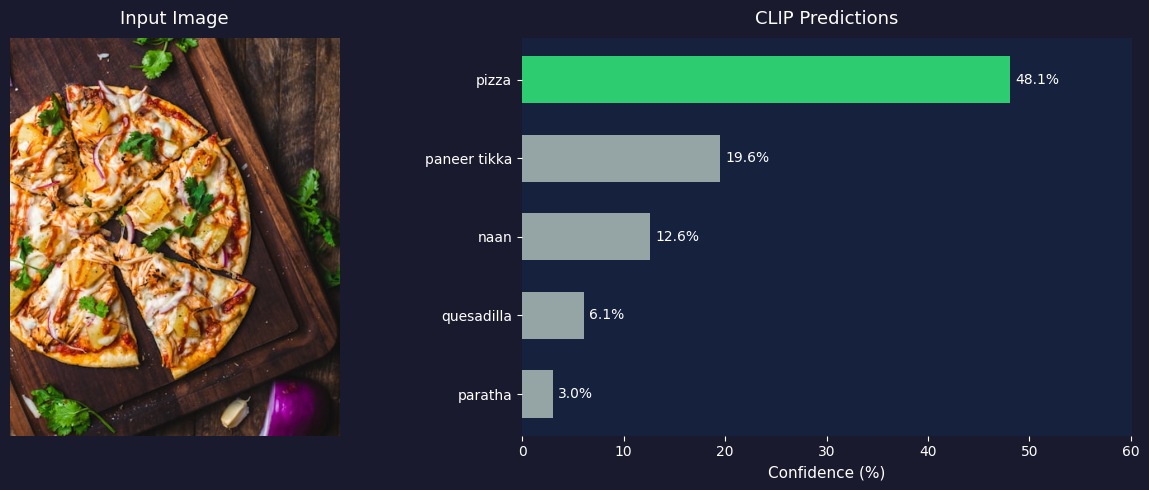


🏆 Top prediction: "PIZZA" (48.1% confidence)


In [20]:
import urllib.request

def load_image(source):
    """
    Load a PIL Image from either a URL or a local file path.
    """
    if isinstance(source, str) and source.startswith('http'):
        # Use urllib with a browser User-Agent to avoid request blocking
        req = urllib.request.Request(source, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req) as response:
            return Image.open(BytesIO(response.read())).convert('RGB')
    return Image.open(source).convert('RGB')

# Test 1: Pizza
print('═' * 50)
print('TEST 1: Pizza')
print('═' * 50)
results = display_prediction(
    'https://images.unsplash.com/photo-1565299624946-b28f40a0ae38?w=400'
)

══════════════════════════════════════════════════
TEST 2: Banana
══════════════════════════════════════════════════


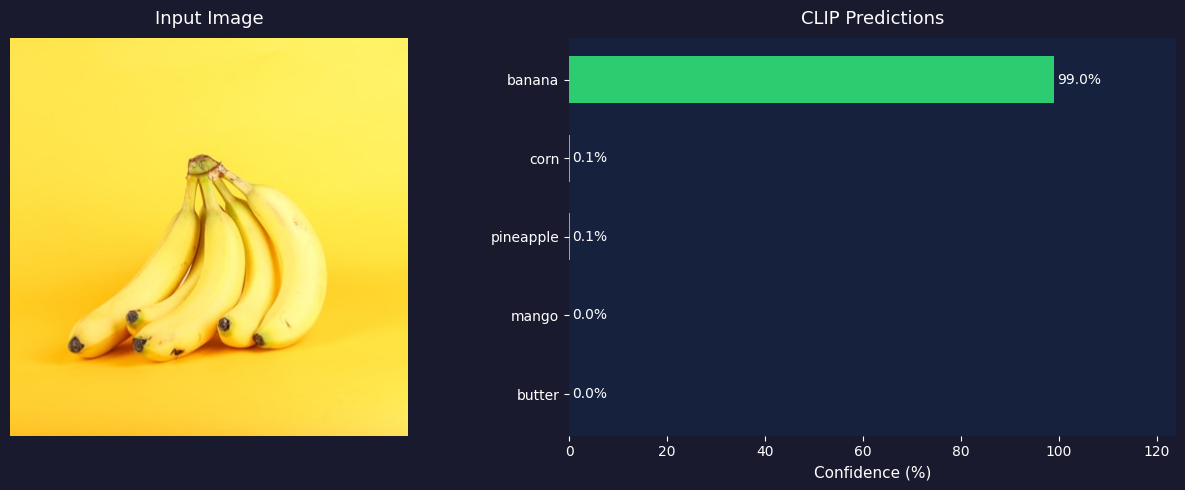


🏆 Top prediction: "BANANA" (99.0% confidence)


In [21]:
# Test 2: Banana
print('═' * 50)
print('TEST 2: Banana')
print('═' * 50)
results = display_prediction(
    'https://images.unsplash.com/photo-1571771894821-ce9b6c11b08e?w=400'
)

Select a food image to upload...


Saving bis.jpg to bis.jpg

Running prediction on: bis.jpg


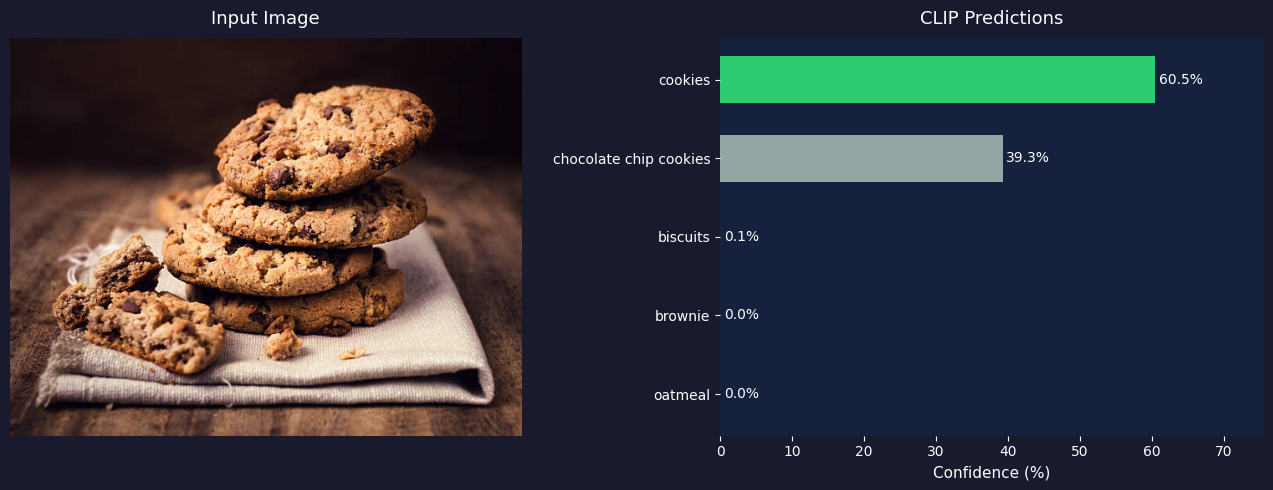


🏆 Top prediction: "COOKIES" (60.5% confidence)


In [22]:
# Upload any food photo from your computer
print('Select a food image to upload...')
uploaded = files.upload()

if uploaded:
    filename = list(uploaded.keys())[0]
    filepath = f'/content/{filename}'
    print(f'\nRunning prediction on: {filename}')
    results = display_prediction(filepath)
else:
    print('No file uploaded.')

In [23]:
!pip install -q sentence-transformers faiss-cpu numpy pandas
print('✅ Dependencies installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 16.4 MB/s eta 0:00:00
✅ Dependencies installed


In [24]:
import os
import pickle
import numpy as np
import pandas as pd
import faiss
from sentence_transformers import SentenceTransformer
from google.colab import drive
import warnings
warnings.filterwarnings('ignore')

drive.mount('/content/drive')

# ─── CONFIGURE YOUR PATH ─────────────────────────────────────────────────
BASE       = '/content/drive/MyDrive/'                   # Same as Steps 1 & 2
OUTPUT_DIR = BASE + 'nutrition_assistant_outputs/'
# ─────────────────────────────────────────────────────────────────────────

print('✅ Libraries ready')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Libraries ready


In [25]:
recipes_df = pd.read_csv(OUTPUT_DIR + 'recipes_clean.csv')
recipes_df = recipes_df.dropna(subset=['full_text']).reset_index(drop=True)

print(f'✅ Recipes loaded: {len(recipes_df):,} recipes')
print(f'   Columns: {list(recipes_df.columns)}')
print()
print('Sample recipe:')
print(f'  Title      : {recipes_df.iloc[0]["title"]}')
print(f'  Ingredients: {str(recipes_df.iloc[0]["ingredients_text"])[:120]}...')
print(f'  Full text  : {recipes_df.iloc[0]["full_text"][:150]}...')

✅ Recipes loaded: 2,231,141 recipes
   Columns: ['title', 'title_clean', 'ingredients_text', 'full_text']

Sample recipe:
  Title      : No-Bake Nut Cookies
  Ingredients: 1 c. firmly packed brown sugar, 1/2 c. evaporated milk, 1/2 tsp. vanilla, 1/2 c. broken nuts (pecans), 2 Tbsp. butter or...
  Full text  : No-Bake Nut Cookies. Ingredients: 1 c. firmly packed brown sugar, 1/2 c. evaporated milk, 1/2 tsp. vanilla, 1/2 c. broken nuts (pecans), 2 Tbsp. butte...


In [26]:
# all-MiniLM-L6-v2: fast, lightweight, excellent for semantic similarity
# Downloads ~90MB, cached after first run
print('Loading sentence embedding model...')

EMBED_MODEL = SentenceTransformer('all-MiniLM-L6-v2')

print('✅ Embedding model ready')
print(f'   Embedding dimension: {EMBED_MODEL.get_sentence_embedding_dimension()}')

Loading sentence embedding model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Embedding model ready
   Embedding dimension: 384


In [27]:
# ─── SUBSET SIZE — adjust if needed ──────────────────────────────────────
SAMPLE_SIZE = 50_000   # 50K recipes — plenty for demo, builds in ~2 minutes
# ─────────────────────────────────────────────────────────────────────────

FAISS_INDEX_PATH  = OUTPUT_DIR + 'recipe_faiss.index'
EMBEDDINGS_PATH   = OUTPUT_DIR + 'recipe_embeddings.npy'

if os.path.exists(FAISS_INDEX_PATH) and os.path.exists(EMBEDDINGS_PATH):
    print('📂 Found existing FAISS index. Loading...')
    index             = faiss.read_index(FAISS_INDEX_PATH)
    recipe_embeddings = np.load(EMBEDDINGS_PATH)
    print(f'✅ Index loaded: {index.ntotal:,} recipes indexed')

else:
    # Sample a diverse subset instead of encoding all 2.2M recipes
    recipes_subset = recipes_df.sample(n=min(SAMPLE_SIZE, len(recipes_df)),
                                       random_state=42).reset_index(drop=True)

    # IMPORTANT: reassign so search functions use the same subset
    recipes_df = recipes_subset

    print(f'Building FAISS index for {len(recipes_df):,} recipes...')

    recipe_embeddings = EMBED_MODEL.encode(
        recipes_df['full_text'].tolist(),
        batch_size=512,           # larger batch = faster on GPU
        show_progress_bar=True,
        convert_to_numpy=True
    )

    faiss.normalize_L2(recipe_embeddings)

    DIM   = recipe_embeddings.shape[1]
    index = faiss.IndexFlatIP(DIM)
    index.add(recipe_embeddings)

    faiss.write_index(index, FAISS_INDEX_PATH)
    np.save(EMBEDDINGS_PATH, recipe_embeddings)
    recipes_df.to_csv(OUTPUT_DIR + 'recipes_subset.csv', index=False)

    print(f'✅ FAISS index built: {index.ntotal:,} recipes indexed')

📂 Found existing FAISS index. Loading...
✅ Index loaded: 50,000 recipes indexed


In [28]:
def search_recipes(query: str, top_k: int = 5) -> pd.DataFrame:
    """
    Search for recipes semantically similar to the query.

    Args:
        query  : food name or natural language query
                 e.g. 'chicken curry', 'low sugar dessert with banana'
        top_k  : number of recipes to return

    Returns:
        DataFrame of top_k matching recipes with similarity scores
    """
    # Encode query
    query_embed = EMBED_MODEL.encode([query], convert_to_numpy=True)
    faiss.normalize_L2(query_embed)

    # Search FAISS index
    scores, indices = index.search(query_embed, top_k)

    # Build results DataFrame
    results = recipes_df.iloc[indices[0]].copy()
    results['similarity_score'] = scores[0]
    results = results.reset_index(drop=True)

    return results[['title', 'ingredients_text', 'similarity_score']]


def format_recipes_for_llm(query: str, top_k: int = 3) -> str:
    """
    Returns a formatted string of top matching recipes.
    This is passed as context to the LLM chatbot in Step 4.

    Args:
        query : food name or question
        top_k : number of recipes to include as context

    Returns:
        Formatted string with recipe titles and ingredients
    """
    results = search_recipes(query, top_k=top_k)

    if results.empty:
        return 'No matching recipes found in the database.'

    context = f'TOP {top_k} MATCHING RECIPES FOR "{query.upper()}":\n'
    context += '─' * 50 + '\n'

    for i, row in results.iterrows():
        context += f'Recipe {i+1}: {row["title"]}\n'
        context += f'Ingredients: {row["ingredients_text"]}\n'
        context += f'Match Score: {row["similarity_score"]:.3f}\n\n'

    return context.strip()


def suggest_healthier_recipes(food_name: str, avoid: list = None) -> str:
    """
    Find healthier recipe alternatives for a given food.
    Optionally exclude foods to avoid (e.g. ['sugar', 'cream', 'butter']).

    Args:
        food_name : identified food name
        avoid     : list of ingredients to avoid

    Returns:
        Formatted string of healthier alternatives
    """
    query   = f'healthy low calorie {food_name} recipe'
    results = search_recipes(query, top_k=5)

    if avoid:
        # Filter out recipes containing avoided ingredients
        avoid_lower = [a.lower() for a in avoid]
        def has_avoided(ingredients):
            ing_lower = str(ingredients).lower()
            return any(a in ing_lower for a in avoid_lower)
        results = results[~results['ingredients_text'].apply(has_avoided)]

    if results.empty:
        return f'No healthier alternatives found for {food_name}.'

    context  = f'HEALTHIER ALTERNATIVES FOR "{food_name.upper()}":\n'
    context += '─' * 50 + '\n'
    for i, row in results.head(3).iterrows():
        context += f'Option {i+1}: {row["title"]}\n'
        context += f'Ingredients: {row["ingredients_text"]}\n\n'

    return context.strip()


print('✅ Recipe search functions ready')

✅ Recipe search functions ready


In [29]:
print('═' * 55)
print('TEST 1: Search for chicken recipes')
print('═' * 55)
results = search_recipes('chicken', top_k=5)
display(results)

print()
print('═' * 55)
print('TEST 2: Search for low sugar dessert')
print('═' * 55)
results = search_recipes('low sugar dessert chocolate', top_k=5)
display(results)

═══════════════════════════════════════════════════════
TEST 1: Search for chicken recipes
═══════════════════════════════════════════════════════


,title,ingredients_text,similarity_score
0,Tex-Mex Meatball Soup,"1 onion, 1 zucchini, 1/2 lb. ground beef, 1 ts...",0.612057
1,Pecan Pie,"1/2 c. white sugar, 1 c. white Karo syrup, 3 e...",0.605606
2,Swiss Steak Deluxe,"1 1/2 to 2 lb. round steak, cut in serving siz...",0.594304
3,Southern Pie,"1 c. sugar, 1/2 c. butter, 1 Tbsp. vinegar, 1 ...",0.581655
4,Waldorf Astoria Cake,"1/2 c. Crisco, 1 1/2 c. sugar, 2 eggs, 2 c. fl...",0.560611



═══════════════════════════════════════════════════════
TEST 2: Search for low sugar dessert
═══════════════════════════════════════════════════════


,title,ingredients_text,similarity_score
0,Piquant Rutabaga,"2 c. diced rutabaga, 1 Tbsp. margarine, 2 Tbsp...",0.653358
1,Half And Half Deli Pickles,"7 c. cold water, 1/2 c. kosher salt, 2 Tbsp. p...",0.641284
2,Blueberry Sugar Cookies,"2 c. sugar, 1 c. margarine, 3 eggs, 1 c. milk,...",0.634737
3,Reuben Sandwich,"8 slices sourdough bread, 1/2 lb. corned beef,...",0.628345
4,Velvety Homemade Pumpkin Pie,"1 1/2 c. mashed pumpkin, 3/4 tsp. salt, 1/2 c....",0.627813


In [30]:
print('═' * 55)
print('TEST 3: LLM context block for "pizza"')
print('═' * 55)
context = format_recipes_for_llm('pizza', top_k=3)
print(context)

print()
print('═' * 55)
print('TEST 4: Healthier alternatives for "fried chicken"')
print('═' * 55)
alts = suggest_healthier_recipes('fried chicken', avoid=['cream', 'butter'])
print(alts)

═══════════════════════════════════════════════════════
TEST 3: LLM context block for "pizza"
═══════════════════════════════════════════════════════
TOP 3 MATCHING RECIPES FOR "PIZZA":
──────────────────────────────────────────────────
Recipe 1: Italian Chicken And Potatoes
Ingredients: 1 chicken, cut into pieces, 3 lb. potatoes, cut long and narrow (twice as thick as French fries), 1/4 c. oil, 1/2 tsp. garlic powder or 2 pieces garlic, cut fine
Match Score: 0.643

Recipe 2: Pumpkin Cake Roll
Ingredients: 3 eggs, beaten on high for 1 minute, 1 c. sugar, 2/3 c. pumpkin, 1 tsp. lemon juice, 3/4 c. flour, 1 tsp. baking powder, 2 tsp. cinnamon, 1/2 tsp. nutmeg, 1/2 tsp. salt, 1 c. finely chopped nuts, powdered sugar
Match Score: 0.606

Recipe 3: Cube Steaks Au Poivre
Ingredients: 4 beef cubed steaks, salt and pepper, 3 Tbsp. margarine, 1/3 c. water, 1 Tbsp. lemon juice, 1/2 tsp. Worcestershire sauce
Match Score: 0.592

═══════════════════════════════════════════════════════
TEST 4: Health

In [31]:
def food_name_to_recipe_context(food_name: str) -> dict:
    """
    Given a food name from CLIP (Step 2), returns a full context
    dictionary ready to be passed into the LLM chatbot (Step 4).

    Returns dict with:
      - food_name       : the identified food
      - similar_recipes : formatted top-3 matching recipes
      - healthy_alts    : healthier recipe alternatives
    """
    return {
        'food_name'       : food_name,
        'similar_recipes' : format_recipes_for_llm(food_name, top_k=3),
        'healthy_alts'    : suggest_healthier_recipes(food_name)
    }


# Test the full bridge function
context = food_name_to_recipe_context('pizza')
print(f'Food identified : {context["food_name"]}')
print()
print(context['similar_recipes'])
print()
print(context['healthy_alts'])

Food identified : pizza

TOP 3 MATCHING RECIPES FOR "PIZZA":
──────────────────────────────────────────────────
Recipe 1: Italian Chicken And Potatoes
Ingredients: 1 chicken, cut into pieces, 3 lb. potatoes, cut long and narrow (twice as thick as French fries), 1/4 c. oil, 1/2 tsp. garlic powder or 2 pieces garlic, cut fine
Match Score: 0.643

Recipe 2: Pumpkin Cake Roll
Ingredients: 3 eggs, beaten on high for 1 minute, 1 c. sugar, 2/3 c. pumpkin, 1 tsp. lemon juice, 3/4 c. flour, 1 tsp. baking powder, 2 tsp. cinnamon, 1/2 tsp. nutmeg, 1/2 tsp. salt, 1 c. finely chopped nuts, powdered sugar
Match Score: 0.606

Recipe 3: Cube Steaks Au Poivre
Ingredients: 4 beef cubed steaks, salt and pepper, 3 Tbsp. margarine, 1/3 c. water, 1 Tbsp. lemon juice, 1/2 tsp. Worcestershire sauce
Match Score: 0.592

HEALTHIER ALTERNATIVES FOR "PIZZA":
──────────────────────────────────────────────────
Option 1: Creme Drop Fudge
Ingredients: 1 bag chocolate creme drops, 3/4 c. peanut butter, 1 tsp. vanilla

O

In [32]:
# FAISS index and embeddings already saved in 3.5
# Save a small metadata file for Step 4 to reference

meta = {
    'embed_model_name' : 'all-MiniLM-L6-v2',
    'num_recipes'      : len(recipes_df),
    'faiss_index_path' : FAISS_INDEX_PATH,
    'embeddings_path'  : EMBEDDINGS_PATH,
}

with open(OUTPUT_DIR + 'rag_meta.pkl', 'wb') as f:
    pickle.dump(meta, f)

print('✅ Saved files:')
print(f'   recipe_faiss.index      ← FAISS search index')
print(f'   recipe_embeddings.npy   ← raw embeddings')
print(f'   rag_meta.pkl            ← metadata for Step 4')

✅ Saved files:
   recipe_faiss.index      ← FAISS search index
   recipe_embeddings.npy   ← raw embeddings
   rag_meta.pkl            ← metadata for Step 4


In [33]:
!pip install -q transformers torch torchvision sentence-transformers faiss-cpu gradio Pillow requests accelerate bitsandbytes
print('✅ Dependencies installed')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 17.5 MB/s eta 0:00:00
✅ Dependencies installed


In [34]:
import os, pickle, warnings, urllib.request
import numpy as np
import pandas as pd
import torch
import faiss
import gradio as gr
from PIL import Image
from io import BytesIO
from transformers import (
    CLIPModel, CLIPProcessor,
    AutoTokenizer, AutoModelForCausalLM, pipeline
)
from sentence_transformers import SentenceTransformer
from google.colab import drive
warnings.filterwarnings('ignore')

drive.mount('/content/drive')

# ─── CONFIGURE YOUR PATH ─────────────────────────────────────────────────
BASE       = '/content/drive/MyDrive/'
OUTPUT_DIR = BASE + 'nutrition_assistant_outputs/'
# ─────────────────────────────────────────────────────────────────────────

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Libraries ready | Device: {DEVICE}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Libraries ready | Device: cpu


In [35]:
print('Loading all assets...\n')

# ── Step 1: Master nutrition table ───────────────────────────────────────
nutrition_wide = pd.read_csv(OUTPUT_DIR + 'master_nutrition.csv')
print(f'✅ Nutrition table  : {len(nutrition_wide):,} foods')

# ── Step 2: CLIP model ───────────────────────────────────────────────────
clip_model     = CLIPModel.from_pretrained('openai/clip-vit-base-patch32').to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')
clip_model.eval()
print(f'✅ CLIP model       : loaded')

# ── Step 3: FAISS index + recipes ────────────────────────────────────────
faiss_index    = faiss.read_index(OUTPUT_DIR + 'recipe_faiss.index')
embed_model    = SentenceTransformer('all-MiniLM-L6-v2')
subset_path    = OUTPUT_DIR + 'recipes_subset.csv'
recipes_df     = pd.read_csv(subset_path if os.path.exists(subset_path)
                             else OUTPUT_DIR + 'recipes_clean.csv')
print(f'✅ FAISS index      : {faiss_index.ntotal:,} recipes')
print(f'✅ Recipes loaded   : {len(recipes_df):,} recipes')

Loading all assets...

✅ Nutrition table  : 7,793 foods


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ CLIP model       : loaded


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ FAISS index      : 50,000 recipes
✅ Recipes loaded   : 50,000 recipes


In [36]:
FOOD_LABELS = [
    'pizza', 'burger', 'hamburger', 'sandwich', 'hot dog', 'sushi',
    'fried chicken', 'grilled chicken', 'chicken curry', 'butter chicken',
    'biryani', 'fried rice', 'noodles', 'pasta', 'spaghetti', 'lasagna',
    'tacos', 'burrito', 'quesadilla', 'nachos', 'fish and chips',
    'steak', 'grilled fish', 'shrimp', 'soup', 'stew', 'omelette',
    'pancakes', 'waffles', 'french toast', 'scrambled eggs', 'boiled eggs',
    'idli', 'dosa', 'samosa', 'dal', 'palak paneer', 'paneer tikka',
    'roti', 'naan', 'paratha', 'upma', 'poha',
    'french fries', 'onion rings', 'popcorn', 'chips', 'spring rolls',
    'dim sum', 'dumplings', 'kebab', 'cookies', 'chocolate chip cookies',
    'biscuits', 'brownie',
    'apple', 'banana', 'orange', 'mango', 'grapes', 'strawberry',
    'watermelon', 'pineapple', 'avocado', 'blueberries', 'peach',
    'salad', 'broccoli', 'carrot', 'tomato', 'cucumber', 'corn',
    'spinach', 'mushroom', 'bell pepper', 'cauliflower', 'potato',
    'ice cream', 'cake', 'cupcake', 'donut', 'croissant', 'muffin',
    'bread', 'toast', 'cheese', 'yogurt', 'butter',
    'coffee', 'tea', 'juice', 'smoothie', 'milkshake',
    'rice', 'oatmeal', 'cereal', 'lentils', 'chickpeas', 'beans'
]

LABEL_PROMPTS = [f'a photo of {label}' for label in FOOD_LABELS]

with torch.no_grad():
    text_inputs = clip_processor(text=LABEL_PROMPTS, return_tensors='pt',
                                 padding=True, truncation=True).to(DEVICE)
    raw_out     = clip_model.text_model(**text_inputs)
    text_embeds = clip_model.text_projection(raw_out.pooler_output)
    text_embeds = text_embeds / text_embeds.norm(p=2, dim=-1, keepdim=True)

print(f'✅ CLIP vocabulary  : {len(FOOD_LABELS)} food labels embedded')

✅ CLIP vocabulary  : 99 food labels embedded


In [39]:
from transformers import T5ForConditionalGeneration, T5Tokenizer

print('Loading LLM (Flan-T5-Large)...')

LLM_NAME  = 'google/flan-t5-large'
tokenizer = T5Tokenizer.from_pretrained(LLM_NAME)
llm       = T5ForConditionalGeneration.from_pretrained(
    LLM_NAME,
    device_map='auto'
).to(DEVICE)

print('✅ LLM ready')

Loading LLM (Flan-T5-Large)...


Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ LLM ready


In [47]:
# ── CLIP: Image → Food Name ───────────────────────────────────────────────
def predict_food(image: Image.Image, top_n: int = 5):
    with torch.no_grad():
        inputs       = clip_processor(images=image, return_tensors='pt').to(DEVICE)
        raw_out      = clip_model.vision_model(**inputs)
        image_embeds = clip_model.visual_projection(raw_out.pooler_output)
        image_embeds = image_embeds / image_embeds.norm(p=2, dim=-1, keepdim=True)
        similarity   = (image_embeds @ text_embeds.T).squeeze(0) * 100.0
        probs        = similarity.softmax(dim=-1).cpu().numpy()
    top_idx = probs.argsort()[::-1][:top_n]
    return [{'food': FOOD_LABELS[i], 'confidence': float(probs[i])} for i in top_idx]


# ── USDA: Food Name → Nutrition Summary ──────────────────────────────────
def get_nutrition_summary(food_query: str) -> str:
    query    = food_query.lower().strip()
    keywords = query.split()
    mask     = nutrition_wide['food_name_clean'].str.contains(keywords[0], na=False)
    for kw in keywords[1:]:
        mask &= nutrition_wide['food_name_clean'].str.contains(kw, na=False)
    results = nutrition_wide[mask]
    if results.empty:
        mask    = nutrition_wide['food_name_clean'].str.contains(keywords[0], na=False)
        results = nutrition_wide[mask]
    if results.empty:
        return f'No USDA nutrition data found for "{food_query}".'
    row = results.iloc[0]
    def v(col):
        val = row.get(col)
        return f'{val:.1f}' if pd.notna(val) else 'N/A'
    return f"""NUTRITION (per 100g): {row['food_name']}
Category: {row.get('category_name', 'Unknown')}
Calories: {v('calories_kcal')} kcal | Protein: {v('protein_g')}g | Fat: {v('fat_g')}g
Carbs: {v('carbs_g')}g | Fiber: {v('fiber_g')}g | Sugar: {v('sugar_g')}g
Sodium: {v('sodium_mg')}mg | Cholesterol: {v('cholesterol_mg')}mg
Calcium: {v('calcium_mg')}mg | Iron: {v('iron_mg')}mg
Vitamin C: {v('vitamin_c_mg')}mg | Vitamin A: {v('vitamin_a_mcg')}mcg"""


# ── FAISS: Food Name → Matching Recipes ──────────────────────────────────
def get_recipe_context(food_name: str, top_k: int = 3) -> str:
    query_embed = embed_model.encode([food_name], convert_to_numpy=True)
    faiss.normalize_L2(query_embed)
    scores, indices = faiss_index.search(query_embed, top_k)
    results = recipes_df.iloc[indices[0]].copy()
    results['score'] = scores[0]
    context = f'RELEVANT RECIPES FOR "{food_name}":\n'
    for i, row in results.iterrows():
        context += f'- {row["title"]}: {str(row["ingredients_text"])[:150]}\n'
    return context


# ── LLM: Answer Any Nutrition Question ───────────────────────────────────
def ask_llm(question: str, food_name: str, nutrition_ctx: str, recipe_ctx: str) -> str:
    prompt = f"""You are a helpful nutrition assistant. Use the context below to answer the question.

IDENTIFIED FOOD: {food_name}

{nutrition_ctx}

{recipe_ctx}

USER QUESTION: {question}

Give a clear, helpful, and specific answer based on the nutrition data and recipes above.
Answer:"""

    # Tokenize
    inputs = tokenizer(
        prompt,
        return_tensors='pt',
        max_length=512,
        truncation=True
    ).to(DEVICE)

    # Generate directly — no pipeline
    with torch.no_grad():
        output_ids = llm.generate(
            **inputs,
            max_new_tokens=250,
            num_beams=4,
            early_stopping=True,
            no_repeat_ngram_size=3
        )

    answer = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return answer.strip()


print('✅ All pipeline functions ready')

✅ All pipeline functions ready


In [48]:
app_state = {'food_name': None, 'nutrition': None, 'recipes': None}


def analyze_image(image):
    if image is None:
        return '## ⚠️ Please upload a food image first.', '', '', []

    try:
        # Handle both numpy array and PIL Image inputs
        if not isinstance(image, Image.Image):
            pil_image = Image.fromarray(image).convert('RGB')
        else:
            pil_image = image.convert('RGB')

        predictions = predict_food(pil_image, top_n=5)
        food_name   = predictions[0]['food']
        confidence  = predictions[0]['confidence'] * 100

        nutrition   = get_nutrition_summary(food_name)
        recipes     = get_recipe_context(food_name, top_k=3)

        app_state['food_name'] = food_name
        app_state['nutrition'] = nutrition
        app_state['recipes']   = recipes

        pred_table = [[p['food'].title(), f"{p['confidence']*100:.1f}%"]
                      for p in predictions]

        header = f'## 🍽️ Identified: **{food_name.title()}** ({confidence:.1f}% confidence)'
        return header, nutrition, recipes, pred_table

    except Exception as e:
        return f'## ❌ Error: {str(e)}', '', '', []


def chat(user_message, history):
    if not user_message or not user_message.strip():
        return history

    if app_state['food_name'] is None:
        response = '⚠️ Please upload and analyze a food image first!'
    else:
        try:
            response = ask_llm(
                question      = user_message,
                food_name     = app_state['food_name'],
                nutrition_ctx = app_state['nutrition'],
                recipe_ctx    = app_state['recipes']
            )
        except Exception as e:
            response = f'Error generating response: {str(e)}'

    history.append({'role': 'user',      'content': user_message})
    history.append({'role': 'assistant', 'content': response})
    return history


# ── Gradio UI ──────────────────────────────────────────────────────────────
with gr.Blocks(theme=gr.themes.Soft(), title='Food Vision Nutrition Assistant') as demo:

    gr.Markdown("""
    # 🍽️ Multimodal Food Recognition & Nutrition Assistant
    **Upload a food photo → Get instant nutrition info + recipes + AI Q&A**
    """)

    with gr.Row():
        with gr.Column(scale=1):
            # Use 'pil' type — most stable across Gradio versions
            image_input = gr.Image(
                label='📸 Upload Food Photo',
                type='pil',                  # ← key fix: PIL instead of numpy
                height=300
            )
            analyze_btn = gr.Button('🔍 Analyze Food', variant='primary', size='lg')
            food_header = gr.Markdown('Upload an image and click Analyze Food')
            pred_table  = gr.Dataframe(
                headers=['Food', 'Confidence'],
                label='Top 5 CLIP Predictions',
                interactive=False
            )

        with gr.Column(scale=1):
            with gr.Tab('🥗 Nutrition Info'):
                nutrition_box = gr.Textbox(
                    label='USDA Nutrition Data (per 100g)',
                    lines=14, interactive=False
                )
            with gr.Tab('📖 Matching Recipes'):
                recipes_box = gr.Textbox(
                    label='Top Matching Recipes from Dataset',
                    lines=14, interactive=False
                )

    gr.Markdown('---')
    gr.Markdown('## 💬 Ask the Nutrition Assistant')

    chatbot = gr.Chatbot(
        label='Nutrition Q&A',
        height=350,
        type='messages'
    )

    with gr.Row():
        chat_input = gr.Textbox(
            placeholder='Ask: "Is this healthy?", "Calories in 250g?", "Healthier alternative?"...',
            label='Your Question',
            scale=5
        )
        chat_btn = gr.Button('Send', variant='primary', scale=1)

    gr.Examples(
        examples=[
            ['Is this food healthy for weight loss?'],
            ['How many calories if I eat 250g of this?'],
            ['Is this safe for a diabetic person?'],
            ['What nutrients am I missing if I eat only this?'],
            ['Give me a healthier recipe alternative.'],
        ],
        inputs=chat_input
    )

    analyze_btn.click(
        fn      = analyze_image,
        inputs  = [image_input],
        outputs = [food_header, nutrition_box, recipes_box, pred_table]
    )

    chat_btn.click(
        fn      = chat,
        inputs  = [chat_input, chatbot],
        outputs = [chatbot]
    ).then(lambda: gr.update(value=''), outputs=[chat_input])

    chat_input.submit(
        fn      = chat,
        inputs  = [chat_input, chatbot],
        outputs = [chatbot]
    ).then(lambda: gr.update(value=''), outputs=[chat_input])

print('✅ Gradio app built')

✅ Gradio app built


In [49]:
# share=True gives you a public URL valid for 72 hours
# Perfect for demos, presentations, and award submissions
demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://97b7792c206f016250.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
